# Brussels Waste Classifier 🗑️♻️

**Objectif :** Construire un modèle de vision par ordinateur capable de reconnaître des déchets ménagers à partir d'une photo, et de recommander la bonne poubelle selon les règles de tri de Bruxelles.

---

## Approche : classification par objet → mapping vers le bin

Plutôt que d'entraîner directement le modèle sur les catégories de poubelles (PMC, papier, verre...), on adopte une approche en deux temps :

1. **Le modèle ML** apprend à reconnaître le type d'objet (bouteille plastique, canette, carton...)
2. **Une règle métier** (dictionnaire Python) mappe ensuite chaque objet vers la bonne poubelle bruxelloise

**Pourquoi ?** PMC regroupe des objets visuellement très différents (plastique, métal, carton à boisson). Un modèle qui apprend des classes visuellement cohérentes sera bien plus précis.

---

## Dataset

- **Source :** [Recyclable and Household Waste Classification](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) (Kaggle)
- **~15 000 images PNG** réparties en **29 classes** d'objets
- Chaque classe contient deux sous-dossiers : `default/` (images studio) et `real_world/` (photos réelles)

---

## Règles de tri Bruxelles (Bruxelles Propreté)

| Poubelle      | Couleur           | Contenu                               |
|---------------|-------------------|---------------------------------------|
| PMC           | Sac bleu          | Plastiques, métaux, cartons à boisson |
| Papier/Carton | Sac jaune         | Papier, carton, journaux              |
| Verre         | Conteneur à verre | Bouteilles et bocaux en verre         |
| Organique     | Sac orange        | Déchets alimentaires                  |
| Résiduel      | Sac noir          | Tout le reste                         |


---

## Plan du notebook

0. [Imports & configuration](#0)
1. [Exploration du dataset](#1)
2. [Mapping objet → poubelle bruxelloise](#2)
3. [Préparation des données (transforms, split train/test)](#3)
4. [Custom Dataset class](#4)
5. [DataLoaders](#5)
6. [Modèle — Transfer Learning avec ResNet50](#6)
7. [Entraînement](#7)
8. [Évaluation](#8)
9. [Prédiction sur une nouvelle image](#9)

## 0. Imports & configuration <a id='0'></a>

In [1]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import random

# Vérification GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device utilisé  : {device}')
print(f'PyTorch         : {torch.__version__}')
print(f'Torchvision     : {torchvision.__version__}')

Device utilisé  : cuda
PyTorch         : 2.11.0+cu128
Torchvision     : 0.26.0+cu128


## 1. Exploration du dataset <a id='1'></a>

Le dataset est organisé ainsi :
```
data/
└── nom_de_classe/
    ├── default/      ← images studio (fond blanc)
    └── real_world/   ← photos en conditions réelles
```
On va combiner les deux sous-dossiers pour chaque classe.

In [2]:
DATA_PATH = Path(r'C:\Users\remyc\PycharmProjects\PythonProject\brussels_waste_classifier\data')

# Récupère toutes les classes (= dossiers de premier niveau)
classes = sorted([d.name for d in DATA_PATH.iterdir() if d.is_dir()])
print(f'{len(classes)} classes trouvées :\n')

total_images = 0
for cls in classes:
    n_default    = len(list((DATA_PATH / cls / 'default').glob('*.png')))
    n_real_world = len(list((DATA_PATH / cls / 'real_world').glob('*.png')))
    n_total      = n_default + n_real_world
    total_images += n_total
    print(f'  {cls:<35} default: {n_default:>3}  real_world: {n_real_world:>3}  total: {n_total:>3}')

print(f'\nTotal : {total_images} images')

29 classes trouvées :

  aerosol_cans                        default: 250  real_world: 250  total: 500
  aluminum_food_cans                  default: 250  real_world: 250  total: 500
  aluminum_soda_cans                  default: 250  real_world: 250  total: 500
  cardboard_boxes                     default: 250  real_world: 250  total: 500
  cardboard_packaging                 default: 250  real_world: 250  total: 500
  clothing                            default: 250  real_world: 250  total: 500
  coffee_grounds                      default: 250  real_world: 250  total: 500
  disposable_plastic_cutlery          default: 250  real_world: 250  total: 500
  eggshells                           default: 250  real_world: 250  total: 500
  food_waste                          default: 250  real_world: 250  total: 500
  glass_beverage_bottles              default: 250  real_world: 250  total: 500
  glass_cosmetic_containers           default: 250  real_world: 250  total: 500
  glass_food_jars

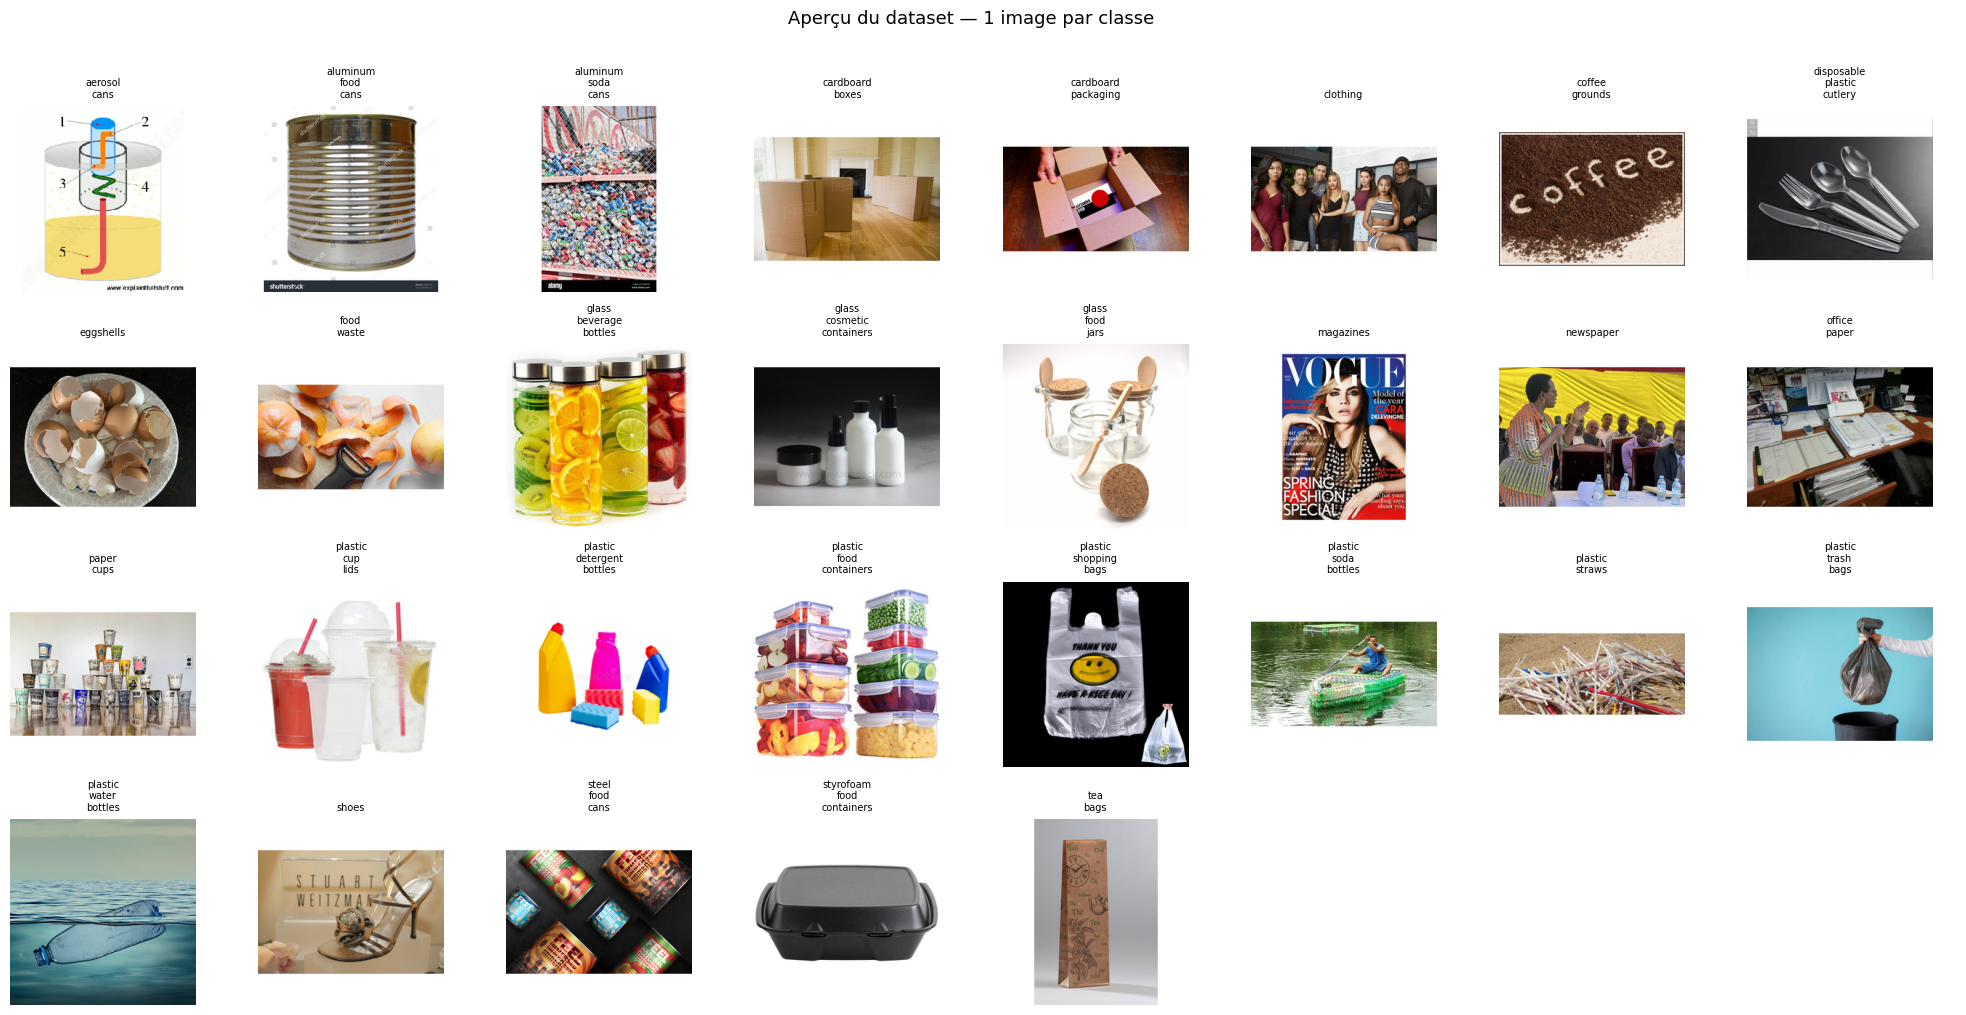

In [3]:
# Visualisation de quelques images par classe
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    # Prend une image real_world si dispo, sinon default
    imgs = list((DATA_PATH / cls / 'real_world').glob('*.png'))
    if not imgs:
        imgs = list((DATA_PATH / cls / 'default').glob('*.png'))
    img = Image.open(random.choice(imgs)).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls.replace('_', '\n'), fontsize=7)
    axes[i].axis('off')

# Cache les axes inutilisés
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Aperçu du dataset — 1 image par classe', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Mapping objet → poubelle bruxelloise <a id='2'></a>

Ce dictionnaire traduit chaque classe du dataset vers la poubelle correspondante selon les règles de **Bruxelles Propreté**.

> ⚠️ Quelques choix discutables à noter :
> - `paper_cups` → `papier` mais souvent résiduel en pratique (gobelet ciré non recyclable)
> - `glass_cosmetic_containers` → `verre` mais Bruxelles Propreté recommande parfois le résiduel selon le type


In [4]:
BRUSSELS_MAPPING = {
    # --- PMC (sac bleu) ---
    'aerosol_cans':                'PMC',
    'aluminum_food_cans':          'PMC',
    'aluminum_soda_cans':          'PMC',
    'cardboard_packaging':         'PMC',
    'plastic_detergent_bottles':   'PMC',
    'plastic_food_containers':     'PMC',
    'plastic_soda_bottles':        'PMC',
    'plastic_water_bottles':       'PMC',

    # --- Papier/Carton (sac jaune) ---
    'cardboard_boxes':             'papier',
    'magazines':                   'papier',
    'newspaper':                   'papier',
    'office_paper':                'papier',

    # --- Verre ---
    'glass_beverage_bottles':      'verre',
    'glass_cosmetic_containers':   'verre',   # ⚠️ voir note ci-dessus
    'glass_food_jars':             'verre',

    # --- Organique (sac orange) ---
    'coffee_grounds':              'organique',
    'eggshells':                   'organique',
    'food_waste':                  'organique',
    'tea_bags':                    'organique',


    # --- Résiduel (sac noir) ---
    'clothing':                    'residuel',
    'disposable_plastic_cutlery':  'residuel',
    'plastic_cup_lids':            'residuel',
    'plastic_shopping_bags':       'residuel',
    'plastic_straws':              'residuel',
    'plastic_trash_bags':          'residuel',
    'shoes':                       'residuel',
    'styrofoam_food_containers':   'residuel',
    'paper_cups':                  'residuel',  # gobelet ciré non recyclable à Bruxelles

}

def get_bin(object_class: str) -> str:
    """Retourne la poubelle bruxelloise pour un type d'objet donné.
    Retourne 'residuel' si la classe est inconnue.
    """
    return BRUSSELS_MAPPING.get(object_class, 'residuel')

# Vérification : toutes les classes du dataset sont-elles mappées ?
print('Vérification du mapping :')
for cls in classes:
    bin_name = get_bin(cls)
    print(f'  {cls:<35} → {bin_name}')

Vérification du mapping :
  aerosol_cans                        → PMC
  aluminum_food_cans                  → PMC
  aluminum_soda_cans                  → PMC
  cardboard_boxes                     → papier
  cardboard_packaging                 → PMC
  clothing                            → residuel
  coffee_grounds                      → organique
  disposable_plastic_cutlery          → residuel
  eggshells                           → organique
  food_waste                          → organique
  glass_beverage_bottles              → verre
  glass_cosmetic_containers           → verre
  glass_food_jars                     → verre
  magazines                           → papier
  newspaper                           → papier
  office_paper                        → papier
  paper_cups                          → residuel
  plastic_cup_lids                    → residuel
  plastic_detergent_bottles           → PMC
  plastic_food_containers             → PMC
  plastic_shopping_bags               

## 3. Préparation des données <a id='3'></a>

Le dataset n'a pas de split train/test prédéfini. On va :
1. Collecter tous les chemins d'images (default + real_world)
2. Faire un split **80% train / 20% test** avec `random_split`

Les transforms sont différentes selon le split :
- `train` : augmentation (flip, rotation, couleur) pour mieux généraliser
- `test` : seulement resize + normalisation ImageNet

In [5]:
# Statistiques ImageNet (standard pour le transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224  # taille attendue par ResNet

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms définis ✅')

Transforms définis ✅


## 4. Custom Dataset class <a id='4'></a>

On suit la structure du cours Daniel Bourke (section 04) : une classe héritant de `torch.utils.data.Dataset` avec `__init__`, `__len__`, et `__getitem__`.

Particularité par rapport au tuto : on collecte les images depuis les deux sous-dossiers `default/` et `real_world/` de chaque classe.

In [6]:
class WasteDataset(Dataset):
    """Dataset de déchets ménagers pour Bruxelles.

    Structure attendue :
        root/
            classe_1/
                default/      ← images .png
                real_world/   ← images .png
            classe_2/
                ...

    Args:
        root      : chemin vers le dossier data/
        transform : transforms à appliquer sur chaque image
        samples   : liste de tuples (path, label) — utile pour passer
                    un subset après random_split
    """

    def __init__(self, root: str, transform=None, samples: list = None):
        self.root      = Path(root)
        self.transform = transform

        # Classes = noms des sous-dossiers de premier niveau
        self.classes      = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        if samples is not None:
            # Sous-ensemble fourni depuis l'extérieur (après split)
            self.samples = samples
        else:
            # Collecte toutes les images (default + real_world)
            self.samples = []
            for cls in self.classes:
                label = self.class_to_idx[cls]
                for subfolder in ['default', 'real_world']:
                    folder = self.root / cls / subfolder
                    if folder.exists():
                        for img_path in folder.glob('*.png'):
                            self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

print('WasteDataset défini ✅')

WasteDataset défini ✅


## 5. DataLoaders <a id='5'></a>

On crée le dataset complet, puis on le divise en **80% train / 20% test** avec `random_split`.
Chaque subset reçoit ensuite son propre transform via un wrapper.

In [7]:
# Dataset complet (sans transform pour l'instant)
full_dataset = WasteDataset(root=DATA_PATH)
print(f'Dataset complet : {len(full_dataset)} images — {len(full_dataset.classes)} classes')

# Split 80/20
torch.manual_seed(42)
train_size = int(0.8 * len(full_dataset))
test_size  = len(full_dataset) - train_size
train_subset, test_subset = random_split(full_dataset, [train_size, test_size])

# Wrapper pour appliquer des transforms différentes à chaque subset
class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = TransformedSubset(train_subset, train_transform)
test_dataset  = TransformedSubset(test_subset,  test_transform)

print(f'Train : {len(train_dataset)} images')
print(f'Test  : {len(test_dataset)} images')

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Vérification d'un batch
images, labels = next(iter(train_loader))
print(f'\nBatch images : {images.shape}')   # [32, 3, 224, 224]
print(f'Batch labels : {labels.shape}')    # [32]

Dataset complet : 14500 images — 29 classes
Train : 11600 images
Test  : 2900 images

Batch images : torch.Size([32, 3, 224, 224])
Batch labels : torch.Size([32])


## 6. Modèle — Transfer Learning avec ResNet50 <a id='6'></a>

On utilise ResNet50 pré-entraîné sur ImageNet. Stratégie :
- **Geler toutes les couches** : le réseau garde ses features ImageNet
- **Remplacer uniquement la couche finale** (`fc`) par une couche adaptée à nos 29 classes
- **Seule la couche `fc` est entraînée** : rapide, peu de risque d'overfitting

In [8]:
# Chargement des poids pré-entraînés ImageNet
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Gel de toutes les couches
for param in model.parameters():
    param.requires_grad = False

# Remplacement de la couche de classification finale
num_classes = len(full_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
# La couche fc est non-gelée par défaut (nouveaux paramètres)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Modèle prêt ✅')
print(f'Classes de sortie        : {num_classes}')
print(f'Paramètres entraînables  : {trainable:,} / {total:,}')

Modèle prêt ✅
Classes de sortie        : 29
Paramètres entraînables  : 59,421 / 23,567,453


## 7. Entraînement <a id='7'></a>

On entraîne uniquement la couche `fc` avec :
- **Loss** : CrossEntropyLoss (standard pour la classification multi-classe)
- **Optimiseur** : Adam avec un learning rate de 1e-3
- **`torch.inference_mode()`** à l'évaluation (recommandé par Bourke vs `no_grad`)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# --- Boucle d'entraînement ---
EPOCHS  = 5
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = eval_epoch(model,  test_loader,  criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}]  '
          f'train loss: {train_loss:.4f}  train acc: {train_acc:.3f}  |  '
          f'test loss: {test_loss:.4f}  test acc: {test_acc:.3f}')

Epoch [1/5]  train loss: 1.5580  train acc: 0.629  |  test loss: 0.8885  test acc: 0.768


## 8. Évaluation <a id='8'></a>

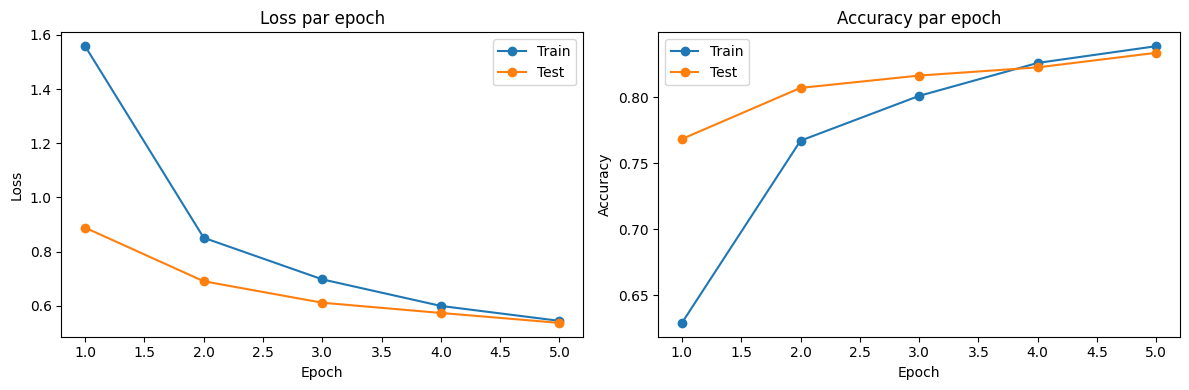


Meilleure accuracy test : 83.3%


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_range, history['test_loss'],  label='Test',  marker='o')
ax1.set_title('Loss par epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train', marker='o')
ax2.plot(epochs_range, history['test_acc'],  label='Test',  marker='o')
ax2.set_title('Accuracy par epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'\nMeilleure accuracy test : {max(history["test_acc"]):.1%}')

## 9. Prédiction sur une nouvelle image <a id='9'></a>

Test end-to-end : on charge une image, le modèle prédit le type d'objet, et la règle métier indique la bonne poubelle bruxelloise.

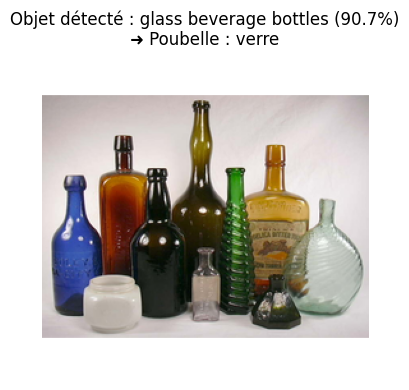

('glass_beverage_bottles', 'verre')

In [11]:
def predict(model, img_path: str, transform, classes: list, device: str):
    """Prédit la classe d'un déchet et retourne la poubelle bruxelloise.

    Args:
        model     : modèle entraîné
        img_path  : chemin vers l'image à prédire
        transform : transform test à appliquer
        classes   : liste des classes du dataset
        device    : 'cuda' ou 'cpu'

    Returns:
        (object_class, bin_name) : type d'objet prédit + poubelle recommandée
    """
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)  # [1, 3, 224, 224]

    with torch.inference_mode():
        output   = model(img_tensor)
        proba    = torch.softmax(output, dim=1)
        conf, pred_idx = proba.max(dim=1)

    object_class = classes[pred_idx.item()]
    bin_name     = get_bin(object_class)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f'Objet détecté : {object_class.replace("_", " ")} ({conf.item():.1%})\n'
        f'➜ Poubelle : {bin_name}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    return object_class, bin_name

# --- Exemple : teste avec une image du dataset ---
sample_img = list((DATA_PATH / 'glass_beverage_bottles' / 'real_world').glob('*.png'))[0]
predict(model, sample_img, test_transform, full_dataset.classes, device)

In [12]:
# Sauvegarde du modèle
import os

MODELS_PATH = Path('models')
MODELS_PATH.mkdir(exist_ok=True)

MODEL_NAME = 'waste_classifier_resnet50_v1.pth'
MODEL_SAVE_PATH = MODELS_PATH / MODEL_NAME

torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f'Modèle sauvegardé → {MODEL_SAVE_PATH}')

Modèle sauvegardé → models\waste_classifier_resnet50_v1.pth


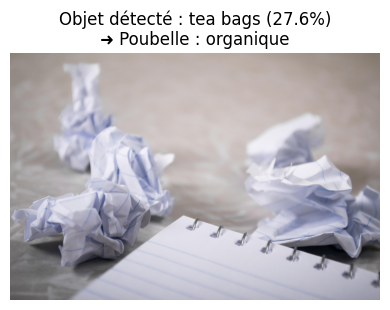

('tea_bags', 'organique')

In [13]:
# Test sur une photo personnelle
MY_IMAGE = Path(r'C:\Users\remyc\PycharmProjects\PythonProject\images test\image5.jpg')  # ← change ici

predict(model, MY_IMAGE, test_transform, full_dataset.classes, device)

---
## 10. Version 2 — Entraînement sur `real_world` uniquement

La v1 était entraînée sur `default/` + `real_world/`. Les images `default/` ont un fond transparent converti en noir, ce qui a biaisé le modèle.

La v2 utilise **uniquement les images `real_world/`** pour que le modèle apprenne sur des conditions proches de la réalité.

In [14]:
# Dataset v2 — real_world uniquement
class WasteDatasetV2(Dataset):
    """Comme WasteDataset mais n'utilise que le sous-dossier real_world/."""

    def __init__(self, root: str, transform=None):
        self.root      = Path(root)
        self.transform = transform

        self.classes      = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            label  = self.class_to_idx[cls]
            folder = self.root / cls / 'real_world'
            if folder.exists():
                for img_path in folder.glob('*.png'):
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Instanciation et split 80/20
full_dataset_v2 = WasteDatasetV2(root=DATA_PATH)

torch.manual_seed(42)
train_size_v2 = int(0.8 * len(full_dataset_v2))
test_size_v2  = len(full_dataset_v2) - train_size_v2
train_subset_v2, test_subset_v2 = random_split(full_dataset_v2, [train_size_v2, test_size_v2])

train_dataset_v2 = TransformedSubset(train_subset_v2, train_transform)
test_dataset_v2  = TransformedSubset(test_subset_v2,  test_transform)

print(f'Dataset v2 (real_world only)')
print(f'Total  : {len(full_dataset_v2)} images')
print(f'Train  : {len(train_dataset_v2)} images')
print(f'Test   : {len(test_dataset_v2)} images')

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader_v2  = DataLoader(test_dataset_v2,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Dataset v2 (real_world only)
Total  : 7250 images
Train  : 5800 images
Test   : 1450 images


In [15]:
# Nouveau modèle v2 (repart de zéro)
model_v2 = resnet50(weights=ResNet50_Weights.DEFAULT)

for param in model_v2.parameters():
    param.requires_grad = False

model_v2.fc = nn.Linear(model_v2.fc.in_features, len(full_dataset_v2.classes))
model_v2    = model_v2.to(device)

criterion_v2 = nn.CrossEntropyLoss()
optimizer_v2 = optim.Adam(model_v2.fc.parameters(), lr=1e-3)

print('Modèle v2 prêt ✅')

Modèle v2 prêt ✅


In [16]:
# Entraînement v2
EPOCHS_V2  = 5
history_v2 = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(EPOCHS_V2):
    train_loss, train_acc = train_epoch(model_v2, train_loader_v2, criterion_v2, optimizer_v2, device)
    test_loss,  test_acc  = eval_epoch(model_v2,  test_loader_v2,  criterion_v2, device)

    history_v2['train_loss'].append(train_loss)
    history_v2['train_acc'].append(train_acc)
    history_v2['test_loss'].append(test_loss)
    history_v2['test_acc'].append(test_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS_V2}]  '
          f'train loss: {train_loss:.4f}  train acc: {train_acc:.3f}  |  '
          f'test loss: {test_loss:.4f}  test acc: {test_acc:.3f}')

Epoch [1/5]  train loss: 2.0203  train acc: 0.541  |  test loss: 1.2674  test acc: 0.723
Epoch [2/5]  train loss: 1.1439  train acc: 0.716  |  test loss: 0.9535  test acc: 0.757
Epoch [3/5]  train loss: 0.9134  train acc: 0.761  |  test loss: 0.8220  test acc: 0.776
Epoch [4/5]  train loss: 0.7693  train acc: 0.792  |  test loss: 0.7560  test acc: 0.787
Epoch [5/5]  train loss: 0.6936  train acc: 0.811  |  test loss: 0.7279  test acc: 0.796


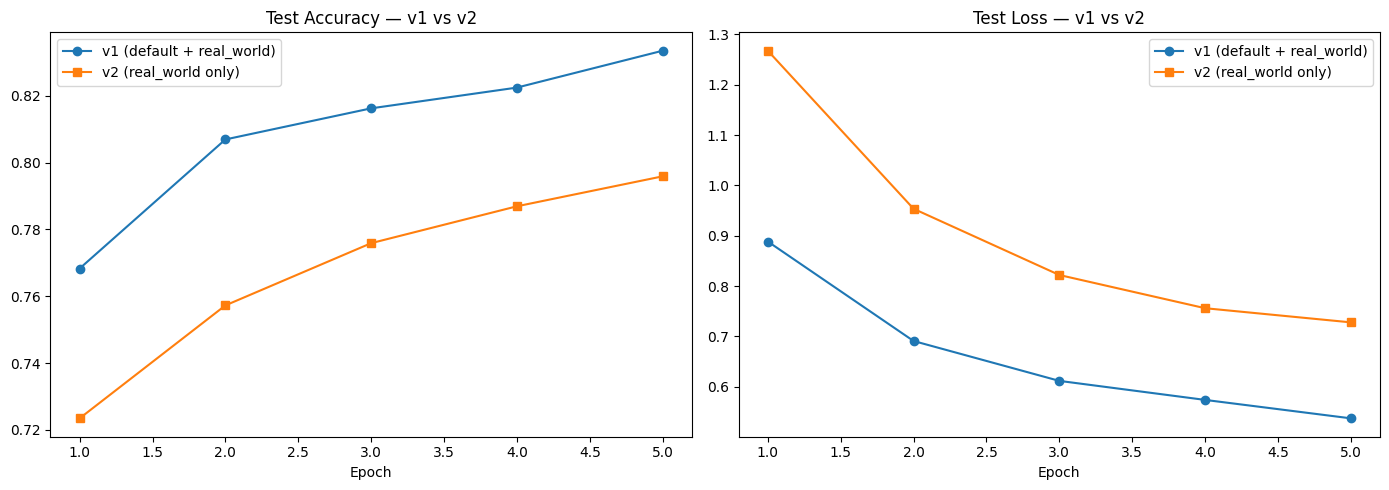

v1 — meilleure test acc : 83.3%
v2 — meilleure test acc : 79.6%


In [17]:
# Courbes v1 vs v2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ['acc', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(range(1, EPOCHS + 1),    history[f'test_{metric}'],    'o-', label='v1 (default + real_world)')
    ax.plot(range(1, EPOCHS_V2 + 1), history_v2[f'test_{metric}'], 's-', label='v2 (real_world only)')
    ax.set_title(f'Test {title} — v1 vs v2')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'v1 — meilleure test acc : {max(history["test_acc"]):.1%}')
print(f'v2 — meilleure test acc : {max(history_v2["test_acc"]):.1%}')

In [18]:
# Sauvegarde v2
MODEL_V2_PATH = MODELS_PATH / 'waste_classifier_resnet50_v2_realworld.pth'
torch.save(model_v2.state_dict(), MODEL_V2_PATH)
print(f'Modèle v2 sauvegardé → {MODEL_V2_PATH}')

Modèle v2 sauvegardé → models\waste_classifier_resnet50_v2_realworld.pth


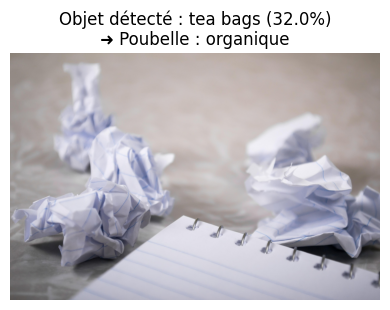

('tea_bags', 'organique')

In [20]:
# Test sur photo personnelle avec le modèle v2
MY_IMAGE = Path(r'C:\Users\remyc\PycharmProjects\PythonProject\images test\image5.jpg')  # ← change ici

predict(model_v2, MY_IMAGE, test_transform, full_dataset_v2.classes, device)

--- Modèle v1 ---


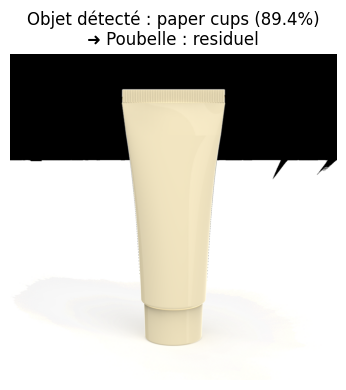

--- Modèle v2 ---


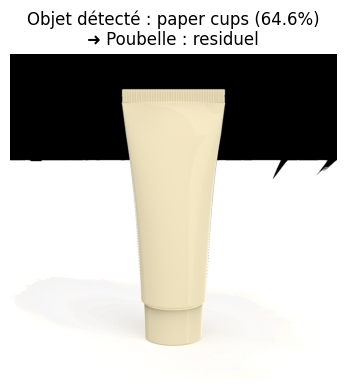

('paper_cups', 'residuel')

In [27]:
MY_IMAGE = Path(r'C:\Users\remyc\PycharmProjects\PythonProject\images test\image6.png')  # ← change ici

print('--- Modèle v1 ---')
predict(model, MY_IMAGE, test_transform, full_dataset.classes, device)

print('--- Modèle v2 ---')
predict(model_v2, MY_IMAGE, test_transform, full_dataset_v2.classes, device)

---
## 11. Version 3 — Split Train / Val / Test rigoureux

En v1 et v2 on utilisait un split 80/20 train/test. Le problème : le set de test contenait des images de dataset différent qui ne collait pas à ce sur quoi il était testé.

En v3 on adopte un split **70% train / 15% val / 15% test** :
- **Train** : le modèle apprend dessus
- **Val** : évalué à chaque epoch pour monitorer l'entraînement
- **Test** : utilisé **une seule fois** à la fin pour mesurer les vraies performances

On garde `real_world` uniquement (comme v2).

In [29]:
# Split 70 / 15 / 15
torch.manual_seed(42)

total = len(full_dataset_v2)
train_size_v3 = int(0.70 * total)
val_size_v3   = int(0.15 * total)
test_size_v3  = total - train_size_v3 - val_size_v3  # le reste pour éviter les arrondis

train_subset_v3, val_subset_v3, test_subset_v3 = random_split(
    full_dataset_v2,
    [train_size_v3, val_size_v3, test_size_v3]
)

train_dataset_v3 = TransformedSubset(train_subset_v3, train_transform)
val_dataset_v3   = TransformedSubset(val_subset_v3,   test_transform)  # pas d'augmentation sur val
test_dataset_v3  = TransformedSubset(test_subset_v3,  test_transform)  # pas d'augmentation sur test

print(f'Dataset v3 (real_world only) — split 70/15/15')
print(f'Total  : {total} images')
print(f'Train  : {len(train_dataset_v3)} images ({len(train_dataset_v3)/total:.0%})')
print(f'Val    : {len(val_dataset_v3)} images ({len(val_dataset_v3)/total:.0%})')
print(f'Test   : {len(test_dataset_v3)} images ({len(test_dataset_v3)/total:.0%})')

train_loader_v3 = DataLoader(train_dataset_v3, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_v3   = DataLoader(val_dataset_v3,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_v3  = DataLoader(test_dataset_v3,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Dataset v3 (real_world only) — split 70/15/15
Total  : 7250 images
Train  : 5075 images (70%)
Val    : 1087 images (15%)
Test   : 1088 images (15%)


In [30]:
# Modèle v3
model_v3 = resnet50(weights=ResNet50_Weights.DEFAULT)

for param in model_v3.parameters():
    param.requires_grad = False

model_v3.fc = nn.Linear(model_v3.fc.in_features, len(full_dataset_v2.classes))
model_v3    = model_v3.to(device)

criterion_v3 = nn.CrossEntropyLoss()
optimizer_v3 = optim.Adam(model_v3.fc.parameters(), lr=1e-3)

print('Modèle v3 prêt ✅')

Modèle v3 prêt ✅


In [31]:
# Entraînement v3 — on monitore sur val, pas sur test
EPOCHS_V3  = 5
history_v3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS_V3):
    train_loss, train_acc = train_epoch(model_v3, train_loader_v3, criterion_v3, optimizer_v3, device)
    val_loss,   val_acc   = eval_epoch(model_v3,  val_loader_v3,   criterion_v3, device)

    history_v3['train_loss'].append(train_loss)
    history_v3['train_acc'].append(train_acc)
    history_v3['val_loss'].append(val_loss)
    history_v3['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS_V3}]  '
          f'train loss: {train_loss:.4f}  train acc: {train_acc:.3f}  |  '
          f'val loss: {val_loss:.4f}  val acc: {val_acc:.3f}')

Epoch [1/5]  train loss: 2.1055  train acc: 0.521  |  val loss: 1.3495  val acc: 0.696
Epoch [2/5]  train loss: 1.1976  train acc: 0.710  |  val loss: 1.0504  val acc: 0.739
Epoch [3/5]  train loss: 0.9535  train acc: 0.754  |  val loss: 0.9137  val acc: 0.752
Epoch [4/5]  train loss: 0.8169  train acc: 0.788  |  val loss: 0.8639  val acc: 0.763
Epoch [5/5]  train loss: 0.7087  train acc: 0.811  |  val loss: 0.8037  val acc: 0.773


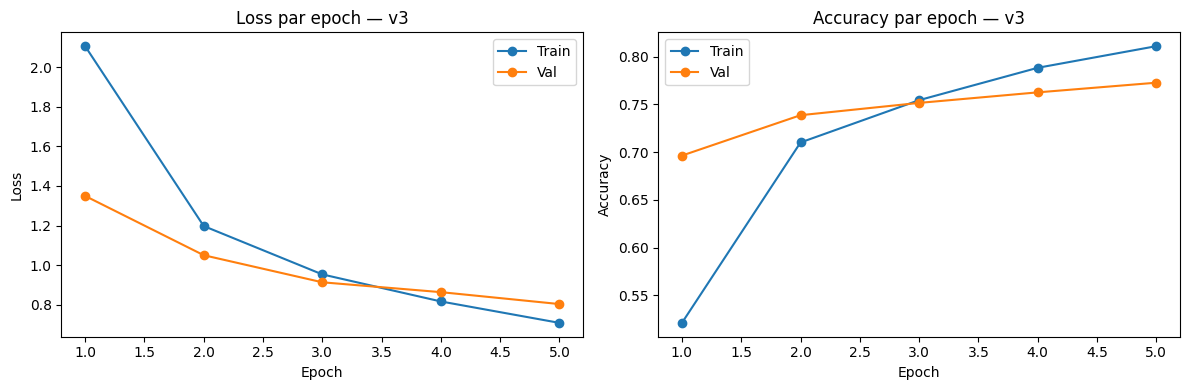

In [32]:
# Courbes train / val
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS_V3 + 1)

ax1.plot(epochs_range, history_v3['train_loss'], 'o-', label='Train')
ax1.plot(epochs_range, history_v3['val_loss'],   'o-', label='Val')
ax1.set_title('Loss par epoch — v3')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, history_v3['train_acc'], 'o-', label='Train')
ax2.plot(epochs_range, history_v3['val_acc'],   'o-', label='Val')
ax2.set_title('Accuracy par epoch — v3')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### Évaluation finale sur le test set

> ⚠️ Cette cellule ne doit être lancée **qu'une seule fois**, quand on est satisfait du modèle. Le test set doit rester vierge jusqu'à la toute fin.

In [33]:
# Évaluation finale — TEST SET (une seule fois !)
test_loss_v3, test_acc_v3 = eval_epoch(model_v3, test_loader_v3, criterion_v3, device)

print('=' * 50)
print(f'Résultats finaux v3 sur le TEST SET')
print('=' * 50)
print(f'Test loss     : {test_loss_v3:.4f}')
print(f'Test accuracy : {test_acc_v3:.1%}')
print()
print(f'Rappel val accuracy : {max(history_v3["val_acc"]):.1%}')

Résultats finaux v3 sur le TEST SET
Test loss     : 0.7057
Test accuracy : 79.1%

Rappel val accuracy : 77.3%


In [34]:
# Sauvegarde v3
MODEL_V3_PATH = MODELS_PATH / 'waste_classifier_resnet50_v3.pth'
torch.save(model_v3.state_dict(), MODEL_V3_PATH)
print(f'Modèle v3 sauvegardé → {MODEL_V3_PATH}')

Modèle v3 sauvegardé → models\waste_classifier_resnet50_v3.pth


--- Modèle v1 (default + real_world) ---


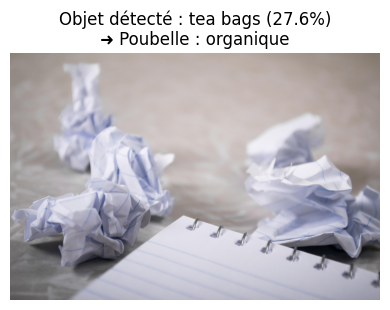

--- Modèle v2 (real_world only) ---


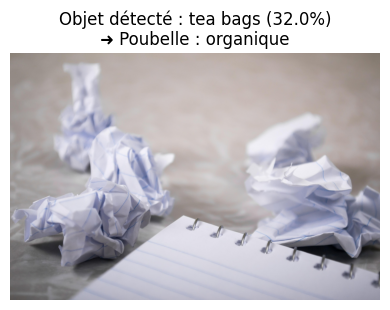

--- Modèle v3 (real_world + split rigoureux) ---


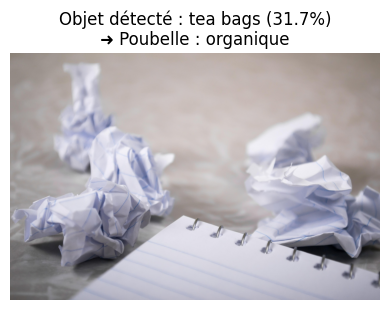

('tea_bags', 'organique')

In [36]:
# Comparaison v1 / v2 / v3 sur une photo perso
MY_IMAGE = Path(r'C:\Users\remyc\PycharmProjects\PythonProject\images test\image5.jpg')  # ← change ici

print('--- Modèle v1 (default + real_world) ---')
predict(model,    MY_IMAGE, test_transform, full_dataset.classes,    device)

print('--- Modèle v2 (real_world only) ---')
predict(model_v2, MY_IMAGE, test_transform, full_dataset_v2.classes, device)

print('--- Modèle v3 (real_world + split rigoureux) ---')
predict(model_v3, MY_IMAGE, test_transform, full_dataset_v2.classes, device)

> ⚠️ **Note : cette comparaison n'est pas représentative**
>
> Les images utilisées ici proviennent d'internet et ne sont pas labelisées.
> Sans labels connus, il est impossible de mesurer objectivement quelle version
> est la meilleure — on ne fait que constater visuellement les prédictions.
>
> Le vrai score de chaque modèle est celui obtenu sur le **test set labelisé**
> dans la cellule précédente. Cette cellule est conservée à titre d'illustration
> uniquement.
>
> Les accuracy des models v1 et v2 précédent ne sont donc pas à prendre en compte.


---
## 12. Visualisation des résultats

Deux visualisations pour comprendre les performances du modèle v3 :
1. **Exemples de prédictions** — images avec prédiction vs vrai label
2. **Confusion matrix** — quelles classes sont confondues entre elles

In [37]:
# Collecte de toutes les prédictions sur le test set
all_preds  = []
all_labels = []
all_images = []

model_v3.eval()
with torch.inference_mode():
    for images, labels in test_loader_v3:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v3(images)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_images.extend(images.cpu())

print(f'Prédictions collectées : {len(all_preds)} images')

Prédictions collectées : 1088 images


### Exemples de prédictions

Vert = bonne prédiction, Rouge = mauvaise prédiction.

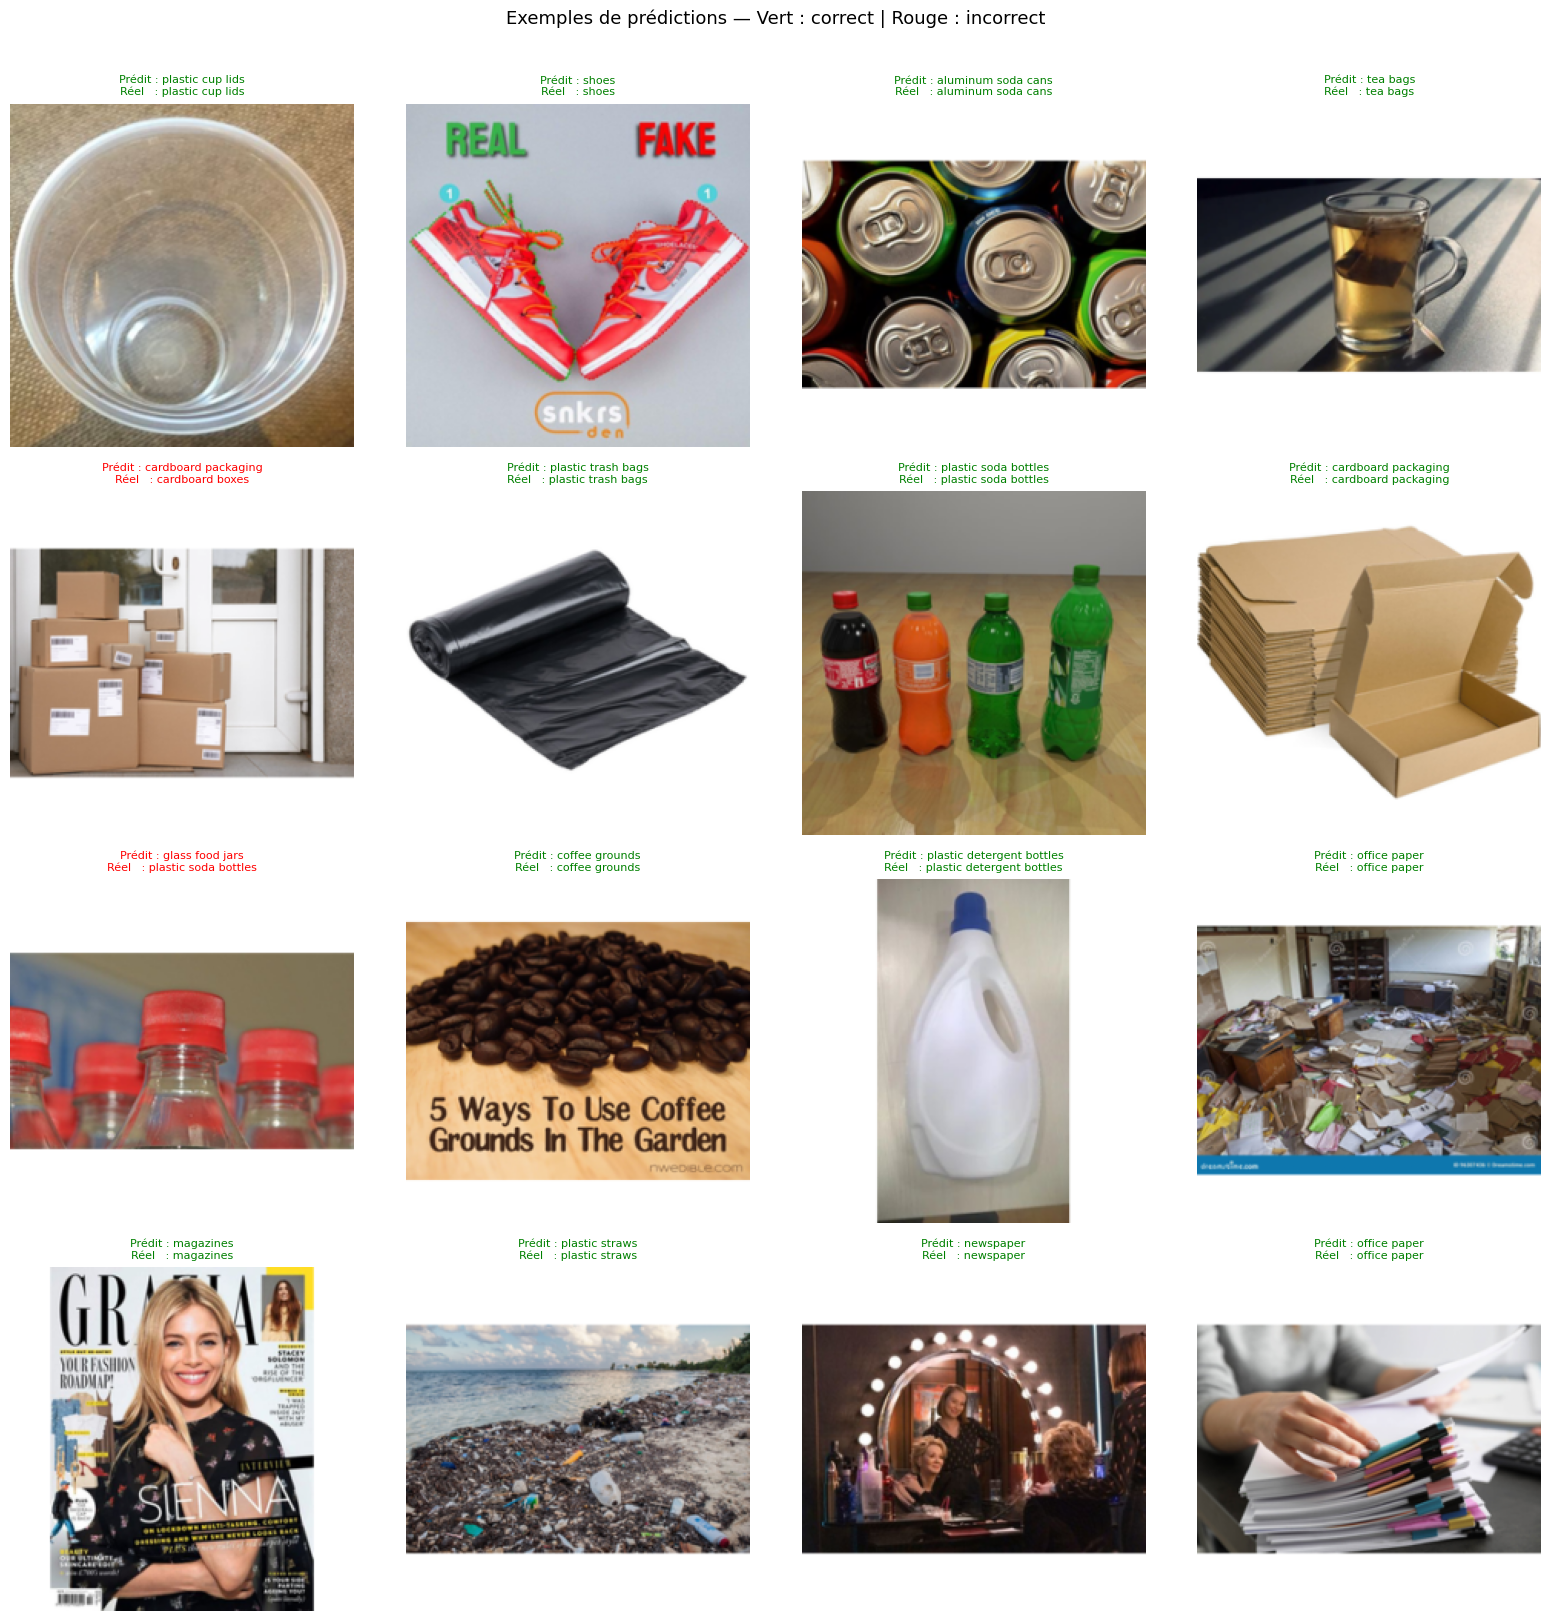

In [38]:
def denormalize(tensor):
    """Inverse la normalisation ImageNet pour afficher l'image correctement."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Affiche 16 prédictions aléatoires
classes = full_dataset_v2.classes
n_display = 16
indices   = random.sample(range(len(all_preds)), n_display)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img   = denormalize(all_images[idx]).permute(1, 2, 0).numpy()
    pred  = all_preds[idx]
    label = all_labels[idx]
    correct = pred == label

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f'Prédit : {classes[pred].replace("_", " ")}\n'
        f'Réel   : {classes[label].replace("_", " ")}',
        fontsize=8,
        color='green' if correct else 'red'
    )

plt.suptitle('Exemples de prédictions — Vert : correct | Rouge : incorrect', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Observations — Exemples de prédictions

La grande majorité des prédictions est correcte (en vert). Les erreurs observées sont cohérentes et compréhensibles :

- **cardboard boxes → cardboard packaging** : les deux classes sont visuellement quasi identiques — même matière, même couleur, seule la forme de l'emballage diffère légèrement
- **glass food jars → plastic soda bottles** : erreur surprenante, probablement due à la forme cylindrique et à des teintes similaires sur certaines images
- **newspaper → ?** : certaines images du dataset `newspaper` sont trompeuses même pour un humain (photos d'articles illustrés, mise en page complexe)

> **Point positif** : aucune confusion absurde (ex: chaussure prédite comme café). Les erreurs restent entre classes visuellement proches.

### Confusion Matrix

Chaque ligne = vrai label, chaque colonne = prédiction du modèle.
La diagonale = bonnes prédictions. Les cases hors diagonale = erreurs.

Plus une case est foncée hors diagonale, plus le modèle confond ces deux classes.

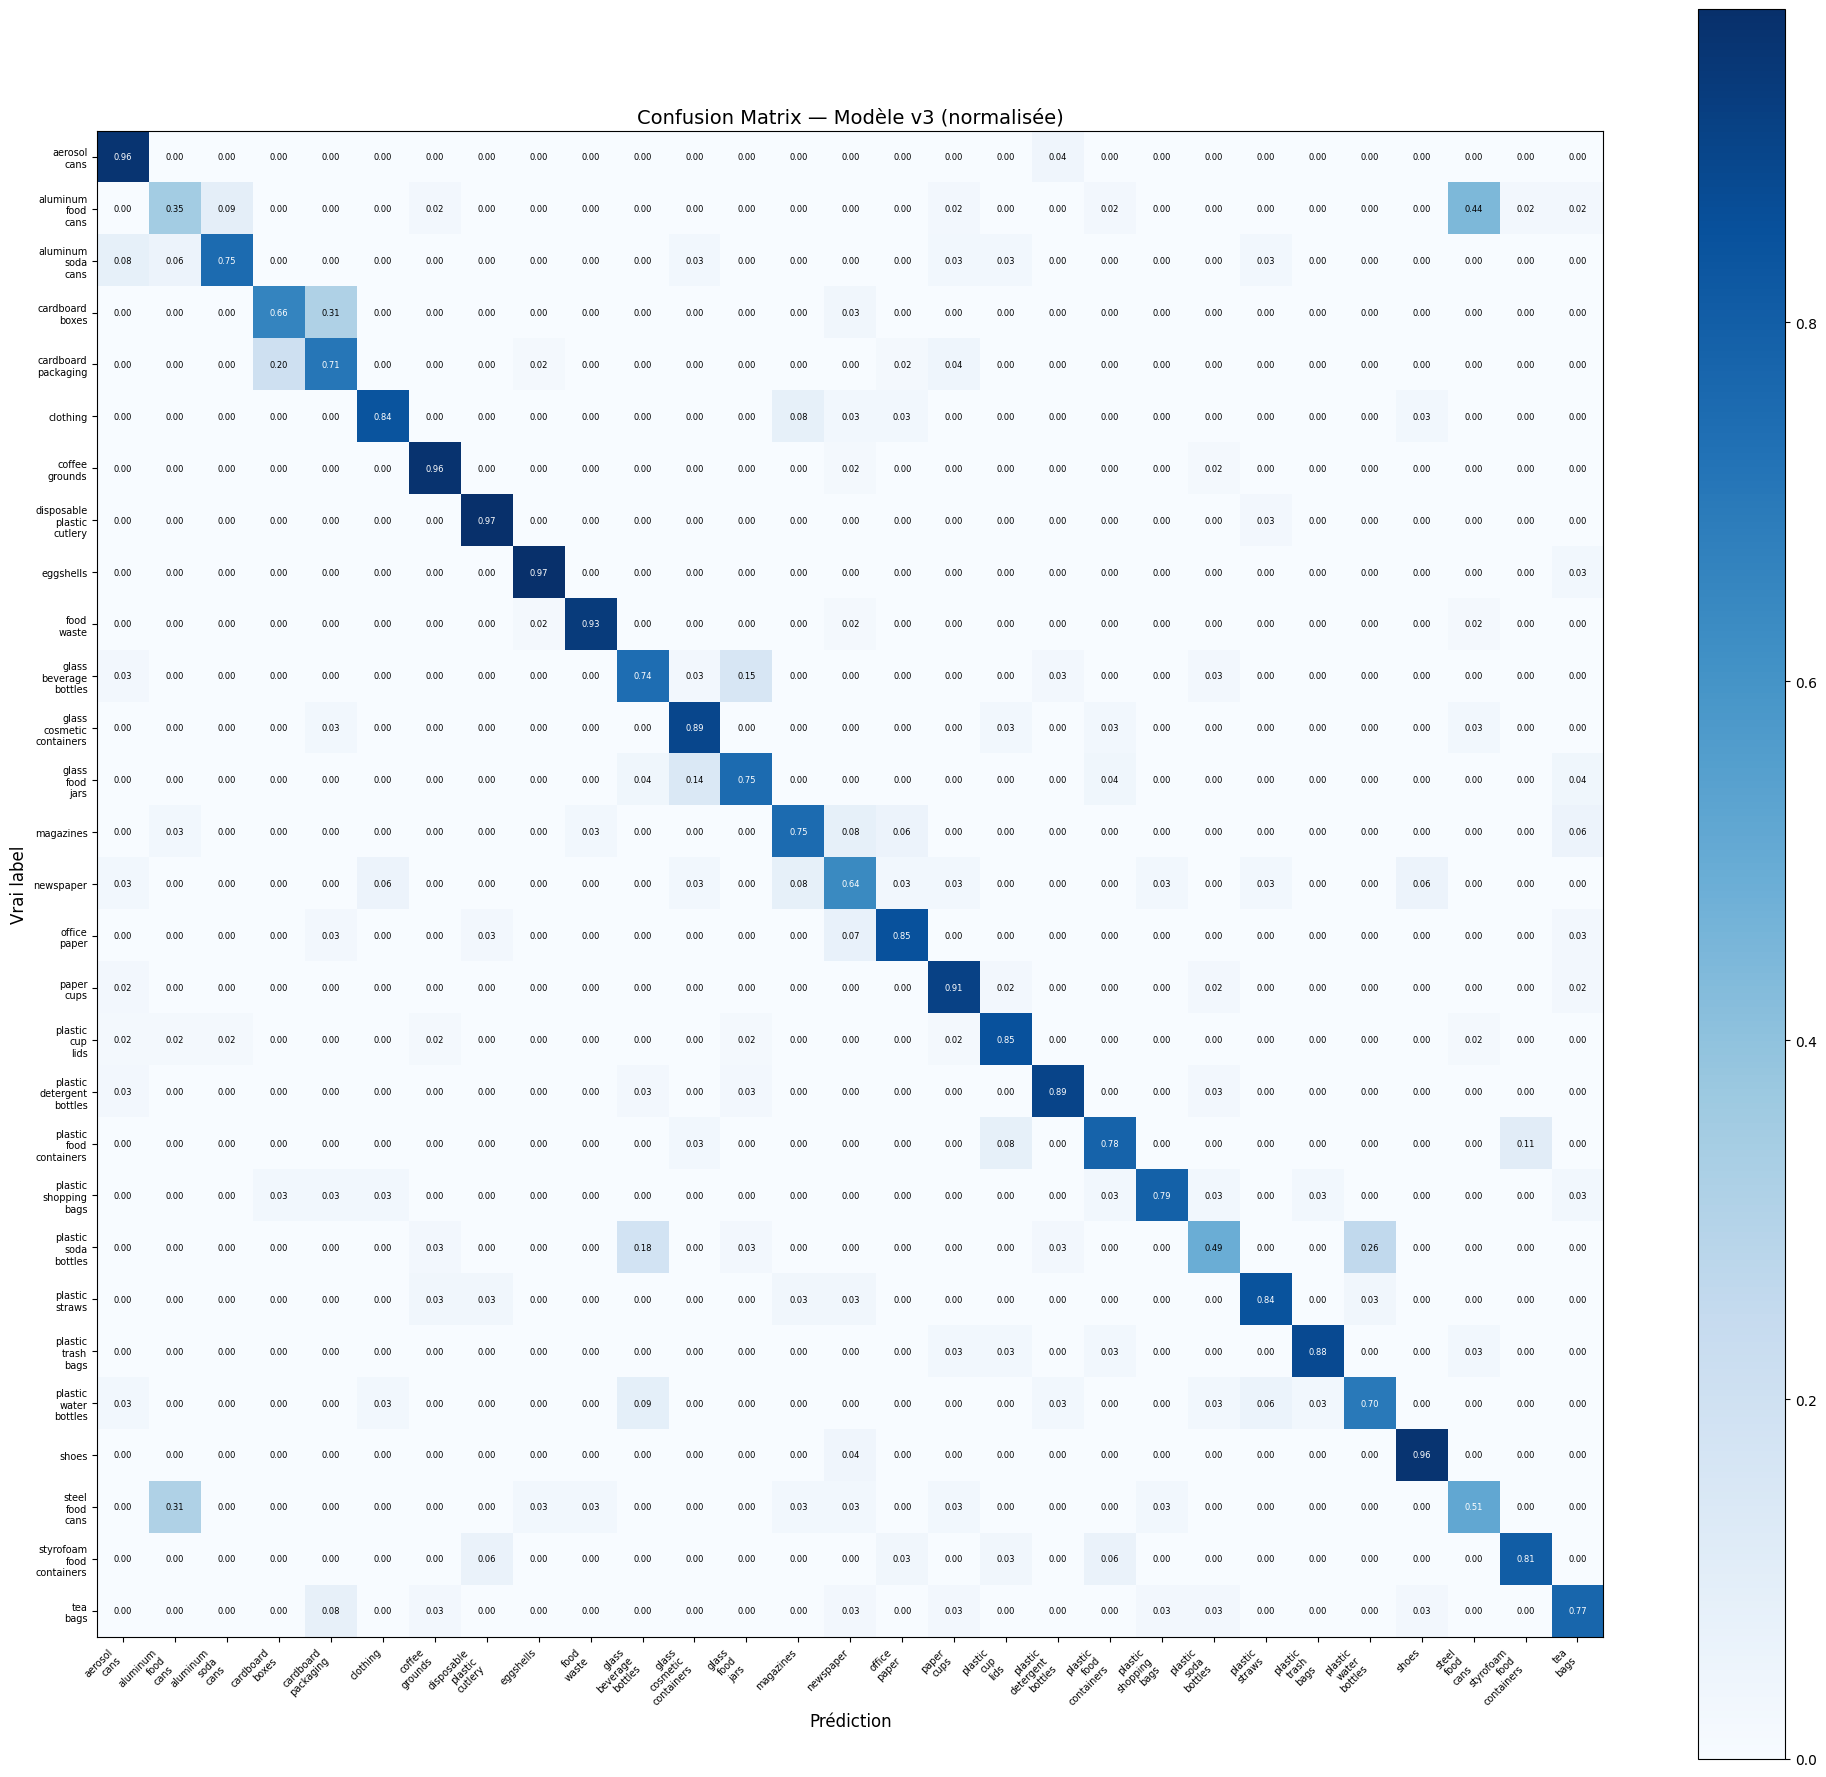

In [39]:
import numpy as np

def plot_confusion_matrix(y_true, y_pred, classes, figsize=(20, 18)):
    """Affiche une confusion matrix normalisée style Bourke."""
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1

    # Normalisation par ligne (en %)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_norm, cmap='Blues')
    plt.colorbar(im, ax=ax)

    # Labels
    labels = [c.replace('_', '\n') for c in classes]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    # Valeurs dans les cases
    for i in range(n):
        for j in range(n):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center',
                    color='white' if val > 0.5 else 'black',
                    fontsize=6)

    ax.set_xlabel('Prédiction', fontsize=12)
    ax.set_ylabel('Vrai label', fontsize=12)
    ax.set_title('Confusion Matrix — Modèle v3 (normalisée)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(all_labels, all_preds, classes)

### Observations — Confusion Matrix

La diagonale est nettement marquée sur l'ensemble des 29 classes — signe que le modèle apprend bien les features distinctives de chaque catégorie.

**Confusions notables hors diagonale :**

| Vrai label | Prédit comme | Taux | Explication |
|---|---|---|---|
| `cardboard_boxes` | `cardboard_packaging` | 31% | Même matière, forme similaire |
| `steel_food_cans` | `aluminum_food_cans` | 31% | Deux types de canettes métalliques quasi identiques |
| `glass_food_jars` | `glass_beverage_bottles` | 14% | Même matière (verre), forme proche |
| `plastic_soda_bottles` | `plastic_water_bottles` | 26% | Visuellement identiques |
| `aluminum_food_cans` | `steel_food_cans` | — | Confusion symétrique avec la ligne ci-dessus |

> **Observation clé pour le projet Bruxelles** : la quasi-totalité des confusions se produisent entre classes qui appartiennent à la **même poubelle**. Par exemple `plastic_soda_bottles` et `plastic_water_bottles` vont toutes deux au **sac bleu (PMC)**. Le mapping vers les poubelles reste donc fiable malgré ces erreurs de classification au niveau objet.

### Classes les plus difficiles

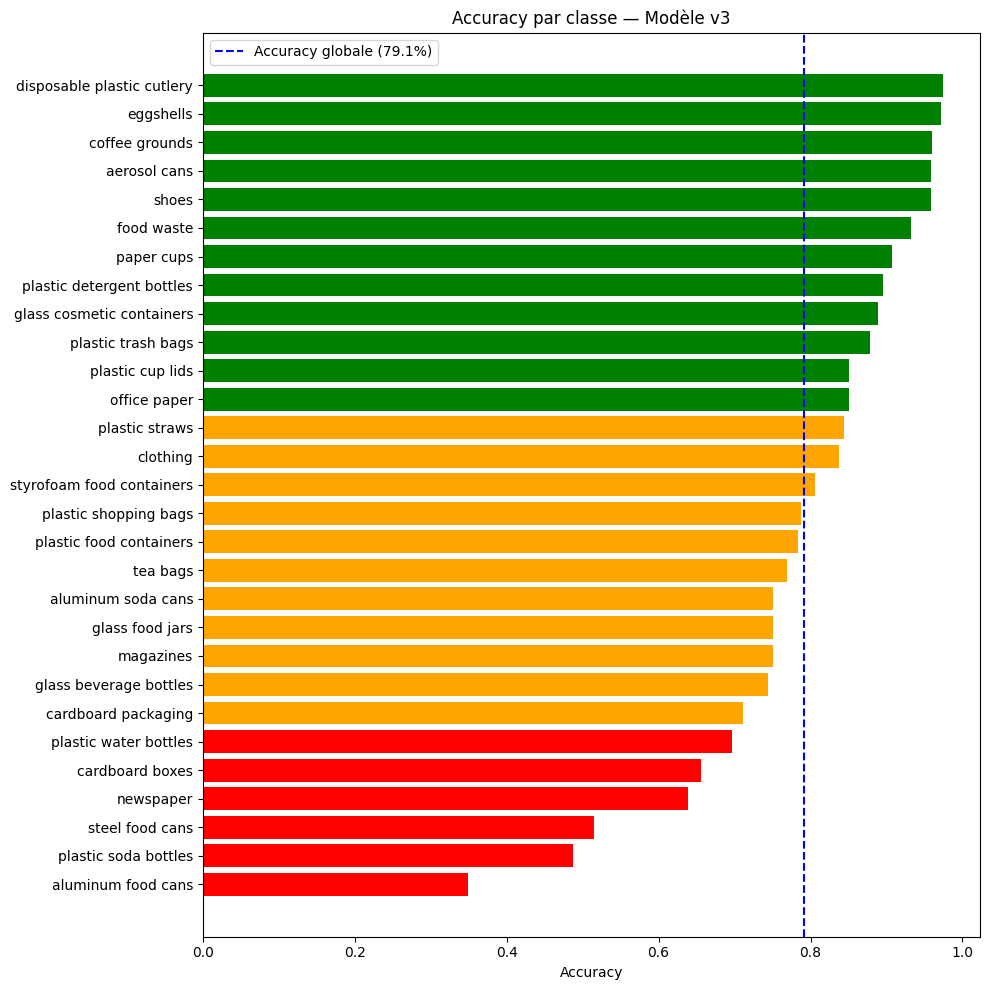

Classes les plus difficiles :
  aluminum_food_cans                  34.9%
  plastic_soda_bottles                48.7%
  steel_food_cans                     51.4%
  newspaper                           63.9%
  cardboard_boxes                     65.6%

Classes les mieux reconnues :
  shoes                               95.8%
  aerosol_cans                        95.8%
  coffee_grounds                      96.0%
  eggshells                           97.1%
  disposable_plastic_cutlery          97.4%


In [40]:
# Accuracy par classe
class_correct = np.zeros(len(classes))
class_total   = np.zeros(len(classes))

for t, p in zip(all_labels, all_preds):
    class_total[t]   += 1
    class_correct[t] += int(t == p)

class_acc = class_correct / class_total

# Tri par accuracy croissante
sorted_idx = np.argsort(class_acc)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(
    [classes[i].replace('_', ' ') for i in sorted_idx],
    [class_acc[i] for i in sorted_idx],
    color=['red' if class_acc[i] < 0.7 else 'orange' if class_acc[i] < 0.85 else 'green'
           for i in sorted_idx]
)

ax.axvline(x=0.791, color='blue', linestyle='--', label=f'Accuracy globale (79.1%)')
ax.set_xlabel('Accuracy')
ax.set_title('Accuracy par classe — Modèle v3')
ax.legend()
plt.tight_layout()
plt.show()

print('Classes les plus difficiles :')
for i in sorted_idx[:5]:
    print(f'  {classes[i]:<35} {class_acc[i]:.1%}')

print('\nClasses les mieux reconnues :')
for i in sorted_idx[-5:]:
    print(f'  {classes[i]:<35} {class_acc[i]:.1%}')

### Observations — Accuracy par classe

**Classes les mieux reconnues (>95%) :**

| Classe | Accuracy | Raison |
|---|---|---|
| `disposable_plastic_cutlery` | 97.4% | Forme très distinctive (fourchettes, couteaux) |
| `eggshells` | 97.1% | Texture et couleur uniques |
| `coffee_grounds` | 96.0% | Texture granuleuse très reconnaissable |
| `aerosol_cans` | 95.8% | Forme cylindrique allongée distinctive |
| `shoes` | 95.8% | Forme très caractéristique |

**Classes les plus difficiles (<55%) :**

| Classe | Accuracy | Raison |
|---|---|---|
| `aluminum_food_cans` | 34.9% | Confondue avec `steel_food_cans` — deux types de canettes métalliques visuellement identiques |
| `plastic_soda_bottles` | 48.7% | Confondue avec `plastic_water_bottles` — forme et transparence identiques |
| `steel_food_cans` | 51.4% | Même problème que `aluminum_food_cans` |
| `newspaper` | 63.9% | Confondu avec `magazines` et `office_paper` — même support papier |
| `cardboard_boxes` | 65.6% | Confondu avec `cardboard_packaging` — même matière |

**Piste d'amélioration pour la v4 :** fusionner les classes trop similaires :
- `aluminum_food_cans` + `steel_food_cans` → `metal_food_cans`
- `plastic_soda_bottles` + `plastic_water_bottles` → `plastic_bottles`
- `cardboard_boxes` + `cardboard_packaging` → `cardboard`

Cette fusion réduirait le nombre de classes de 29 à ~26 tout en améliorant significativement l'accuracy globale.

---
## 13. Conclusion & Bilan

---

### Résumé de l'étude

Ce notebook constitue la première étape d'un projet de classification de déchets ménagers adapté aux règles de tri de **Bruxelles Propreté**. L'approche adoptée est un **transfer learning** sur ResNet50 pré-entraîné sur ImageNet, avec un mapping des prédictions vers les poubelles bruxelloises via un dictionnaire Python.

Trois versions du modèle ont été entraînées et comparées :

| Version | Dataset | Split | Test Accuracy |
|---------|---------|-------|---------------|
| v1 | default + real_world | 80/20 | ~83.3% |
| v2 | real_world uniquement | 80/20 | ~79.6% |
| v3 | real_world uniquement | 70/15/15 | **79.1%** |

> ⚠️ Les accuracy v1 et v2 ne sont pas comparables à la v3 — elles ont été évaluées sur un test set non rigoureux. Seule la v3 dispose d'un vrai test set vierge.

---

### Résultats du modèle v3 (final)

- **Test accuracy globale : 79.1%** sur 1088 images labelisées
- **Classes les mieux reconnues** (>95%) :
  - `disposable_plastic_cutlery` : 97.4%
  - `eggshells` : 97.1%
  - `coffee_grounds` : 96.0%
  - `aerosol_cans` : 95.8%
  - `shoes` : 95.8%

- **Classes les plus difficiles** (<55%) :
  - `aluminum_food_cans` : 34.9%
  - `plastic_soda_bottles` : 48.7%
  - `steel_food_cans` : 51.4%

- **Observation clé** : la majorité des confusions se produisent entre classes qui appartiennent à la **même poubelle bruxelloise** (ex: `plastic_soda_bottles` ↔ `plastic_water_bottles` → tous deux PMC). Le mapping vers les poubelles reste donc fiable malgré ces erreurs de classification.

---

### Erreurs commises & leçons apprises

**1. Versions instables de packages**
Au démarrage du projet, des versions nightly/RC de `matplotlib` (3.11.0rc2) et `torch` (2.9.0+cu130) ont causé des bugs difficiles à diagnostiquer. Toujours privilégier les versions stables.

**2. Biais du fond noir (images default/)**
Les images `default/` ont un fond transparent converti en noir lors du `convert('RGB')`. Inclure ces images en v1 a biaisé le modèle et dégradé ses performances sur des photos réelles. Résolu en v2/v3 en utilisant uniquement `real_world/`.

**3. Test set non rigoureux (v1 et v2)**
Les premières évaluations sur photos personnelles trouvées sur internet, sans labels connus, ne constituaient pas un test valide. Un test rigoureux nécessite des images labelisées issues d'une distribution similaire au dataset d'entraînement.

**4. Split train/test insuffisant**
En v1 et v2, le test set était vu à chaque epoch — il servait en réalité de validation. La v3 corrige cela avec un split **70/15/15** (train/val/test) où le test set est utilisé une seule fois à la fin.

---

### Objectifs futurs

**v4 — Structure ImageFolder (refactoring)**
Reorganiser physiquement les images en dossiers `train/val/test/` pour utiliser `torchvision.ImageFolder` et se rapprocher de la structure standard du cours Daniel Bourke. Supprimer le `TransformedSubset` et `WasteDataset` custom.

**v4 — Fusion des classes similaires**
Fusionner les classes visuellement trop proches pour améliorer l'accuracy :
- `aluminum_food_cans` + `steel_food_cans` → `metal_food_cans`
- `plastic_soda_bottles` + `plastic_water_bottles` → `plastic_bottles`
- `cardboard_boxes` + `cardboard_packaging` → `cardboard`

**v5 — Fine-tuning**
Dégeler les dernières couches de ResNet50 et les réentraîner avec un learning rate très faible pour améliorer la discrimination des classes difficiles.

**v6 — Dataset TACO**
Intégrer le dataset [TACO](http://tacodataset.org/) (Trash Annotations in Context) pour des images de déchets en conditions réelles (rue, nature, poubelles). Plus représentatif que le dataset Kaggle actuel.

**Application**
Développer une application web/mobile permettant de :
- Prendre une photo d'un déchet
- Obtenir la poubelle bruxelloise recommandée
- Afficher les consignes de tri par commune

Stack envisagée : **FastAPI** (backend) + **frontend mobile** (à définir)

---

*Projet réalisé dans le cadre de l'apprentissage du cours [Zero to Mastery PyTorch](https://www.learnpytorch.io/) de Daniel Bourke.*